# Avance 3 — Baseline (Equipo 17, AgroSatCopilot)
## Proyecto Integrador MNA · Tec de Monterrey

**Equipo 17**
- Carlos Isaac Ávila Gutiérrez — A01796035
- Carlos Aaron Bocanegra Buitrón — A01796345
- Arthur Jafed Zizumbo Velasco — A01796363

**Curso:** MNA — Tec de Monterrey · 20-abr → 3-jul-2026
**Fecha de entrega:** 2026-05-20 (con correcciones post-A3 cerradas 2026-05-26).

---

## Resumen ejecutivo

Este notebook consolida el trabajo del **Avance 3 (Baseline)** y las correcciones incorporadas en la iteración posterior. La fase baseline establece el piso de desempeño de los modelos sobre las 85.951 parcelas PASTIS-R y deja un protocolo de evaluación (CV espacial 5-fold con buffer 1 km) reutilizable por las siguientes fases.

El entregable original (`notebooks/baseline/04_baseline.ipynb`) reporta Random Forest y XGBoost con interpretabilidad SHAP y curvas de aprendizaje. La iteración posterior (notebook `05_reencuadre_fenologico.ipynb`) examina cuatro hipótesis de ingeniería de características (leakage geométrico, FarSLIP, descripción fenológica textual y firma espectral) y toma decisiones de promover, descartar o diferir cada bloque. Finalmente, el notebook `04b_baseline_v2.ipynb` reentrena los tres modelos canónicos (XGBoost, TempCNN, InceptionTime) sobre el conjunto saneado para tener un techo cuantificado a batir en la fase de modelos densos.


## Índice

1. [Baseline original — Random Forest y XGBoost](#sec1)
2. [Ablation post-A3 y bloques opcionales](#sec2)
3. [Baseline v2 — 3 modelos sobre el conjunto ganador](#sec3)
4. [Conclusiones consolidadas](#sec4)

Los notebooks de trabajo detallado viven en:

- [`../baseline/04_baseline.ipynb`](../baseline/04_baseline.ipynb)
- [`../baseline/05_reencuadre_fenologico.ipynb`](../baseline/05_reencuadre_fenologico.ipynb)
- [`../baseline/04b_baseline_v2.ipynb`](../baseline/04b_baseline_v2.ipynb)


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib

matplotlib.use('Agg')  # backend headless para papermill
import matplotlib.pyplot as plt  # noqa: E402
import polars as pl  # noqa: E402
from IPython.display import Image, Markdown, display  # noqa: E402

# Bootstrap sys.path para que el notebook pueda importar desde ml/*
_REPO_BOOTSTRAP = Path.cwd().resolve()
for _candidate in (_REPO_BOOTSTRAP, *_REPO_BOOTSTRAP.parents):
    if (_candidate / 'pyproject.toml').is_file():
        _REPO_BOOTSTRAP = _candidate
        break
if str(_REPO_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(_REPO_BOOTSTRAP))

from ml.utils.notebook_setup import find_repo_root  # noqa: E402

%load_ext autoreload
%autoreload 2

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

REPO = find_repo_root()
display(Markdown(f'**Repo bootstrap OK** -> `{REPO.name}`'))


**Repo bootstrap OK** -> `agro_sat_copilot`

<a id="sec1"></a>
## 1. Baseline original — Random Forest y XGBoost

El notebook fuente del Avance 3 entrena Random Forest y XGBoost sobre el vector de características combinado (AlphaEarth 64-dim + índices espectrales + estadísticas temporales + terreno + clima, 187 columnas) y los evalúa con CV espacial 5-fold sobre 85.951 parcelas. El umbral de referencia del baseline es F1-macro >= 0,60.

**Detalle completo:** [`../baseline/04_baseline.ipynb`](../baseline/04_baseline.ipynb).

Resumen de los hallazgos del notebook original:

- XGBoost alcanza un F1-macro ~0,41 sobre las 18 clases efectivas — por debajo del umbral de 0,60. La causa es estructural: las 187 características resumen el año en un solo vector y pierden la dinámica intra-anual que separa cultivos espectralmente parecidos.
- Random Forest y XGBoost rinden parecido dentro de cada escenario; la diferencia grande aparece entre escenarios (AlphaEarth vs Sentinel-2 crudo vs vector combinado).
- Las curvas de aprendizaje confirman que los modelos NO sobreajustan: simplemente han llegado a su techo sobre datos que perdieron la dimensión temporal.
- El análisis SHAP confirma que la mayoría de las top-20 características son dimensiones del embedding AlphaEarth, lo que valida la decisión de tratar el embedding como base del vector combinado.


In [2]:
# Leemos la fila resumen del baseline original desde el ablation
# historico de US-022 (mismo splitter spatial CV 5-fold).
_baseline_table = REPO / 'reports/baseline/reencuadre_fenologico/ablation_table.parquet'
if _baseline_table.exists():
    df_baseline_hist = pl.read_parquet(_baseline_table)
    display(Markdown('**Tabla de ablation historica (US-022) sobre 85.951 parcelas:**'))
    display(df_baseline_hist)
else:
    display(Markdown('Tabla historica no disponible en disco.'))


**Tabla de ablation historica (US-022) sobre 85.951 parcelas:**

feature_set,n_features,f1_macro,f1_weighted,miou,delta_vs_full
str,i64,f64,f64,f64,f64
"""full""",185,0.5167,0.7709,0.3956,null
"""no_geom""",185,0.5167,0.7709,0.3956,0.0
"""no_geom_no_era5_srtm""",185,0.5167,0.7709,0.3956,0.0
"""phenology_only""",32,0.4178,0.6917,0.3007,-0.0989
"""alphaearth_only""",0,NaN,NaN,NaN,null


<a id="sec2"></a>
## 2. Ablation post-A3 y bloques opcionales

Tras el Avance 3 quedaron abiertas cuatro hipótesis de ingeniería de características que afectan la limpieza del baseline. La iteración posterior las evalúa una por una con CV espacial idéntica al del baseline original:

- **H-1 — Leakage geométrico:** las 3 columnas `geom_area`, `geom_perimeter`, `geom_elongation` actúan como proxy de región (parcelas de la misma zona comparten distribución de tamaño y forma). Decisión: **descartar** del baseline definitivo.
- **H-2 — FarSLIP (embeddings visuales):** modelo CLIP fine-tuned sobre PASTIS, evaluado sobre subset matched de 30.173 parcelas. Decisión: **diferir** a la iteración siguiente (deuda US-024) hasta extender el matching al dataset completo.
- **H-3 — Descripción fenológica textual vía Gemini Flash 3.5:** prompt agronómico generado para 1.080 parcelas balanceadas (60 por clase x 18 clases), encodeado con sentence-transformers a 384 dim. Costo real medido: $0.49 USD. Decisión: **diferir** (delta vs full = -0.0354, por debajo del umbral de promoción).
- **H-4 — Firma espectral (Red Edge Position, Frampton et al. 2013):** descriptor compacto derivado de las bandas red-edge Sentinel-2 en los anclajes fenológicos. Decisión: **diferir** salvo confirmación en futuras corridas.

**Detalle completo:** [`../baseline/05_reencuadre_fenologico.ipynb`](../baseline/05_reencuadre_fenologico.ipynb).


In [3]:
# Tabla consolidada de los bloques opcionales evaluados.
# Une la ablation historica (US-022, 5 conjuntos canonicos) con la
# ablation real de pheno_text (US-023-preview P4, 1080 parcelas).
_abl_hist_path = REPO / 'reports/baseline/reencuadre_fenologico/ablation_table.parquet'
_abl_p4_path = (
    REPO / 'reports/baseline/feature_ablation/ablation_table_pheno_text_v2.parquet'
)

df_abl_p4 = pl.read_parquet(_abl_p4_path).select([
    'feature_set', 'n_features', 'f1_macro', 'f1_weighted', 'miou', 'delta_vs_full',
])
display(Markdown('**Ablation real (pheno_text via Gemini Flash 3.5, 1080 parcelas):**'))
display(df_abl_p4)

if _abl_hist_path.exists():
    df_abl_hist = pl.read_parquet(_abl_hist_path).select([
        'feature_set', 'n_features', 'f1_macro', 'f1_weighted', 'miou', 'delta_vs_full',
    ])
    display(Markdown('**Ablation historica (5 conjuntos canonicos sobre dataset full):**'))
    display(df_abl_hist)


**Ablation real (pheno_text via Gemini Flash 3.5, 1080 parcelas):**

feature_set,n_features,f1_macro,f1_weighted,miou,delta_vs_full
str,i64,f64,f64,f64,f64
"""full""",185,0.328598,0.328598,0.212026,null
"""with_pheno_text""",569,0.293236,0.293236,0.18701,-0.035362
"""pheno_text_only""",384,0.074728,0.074728,0.039618,-0.25387


**Ablation historica (5 conjuntos canonicos sobre dataset full):**

feature_set,n_features,f1_macro,f1_weighted,miou,delta_vs_full
str,i64,f64,f64,f64,f64
"""full""",185,0.5167,0.7709,0.3956,null
"""no_geom""",185,0.5167,0.7709,0.3956,0.0
"""no_geom_no_era5_srtm""",185,0.5167,0.7709,0.3956,0.0
"""phenology_only""",32,0.4178,0.6917,0.3007,-0.0989
"""alphaearth_only""",0,NaN,NaN,NaN,null


**Figura — bloques opcionales evaluados contra el conjunto `full`:**

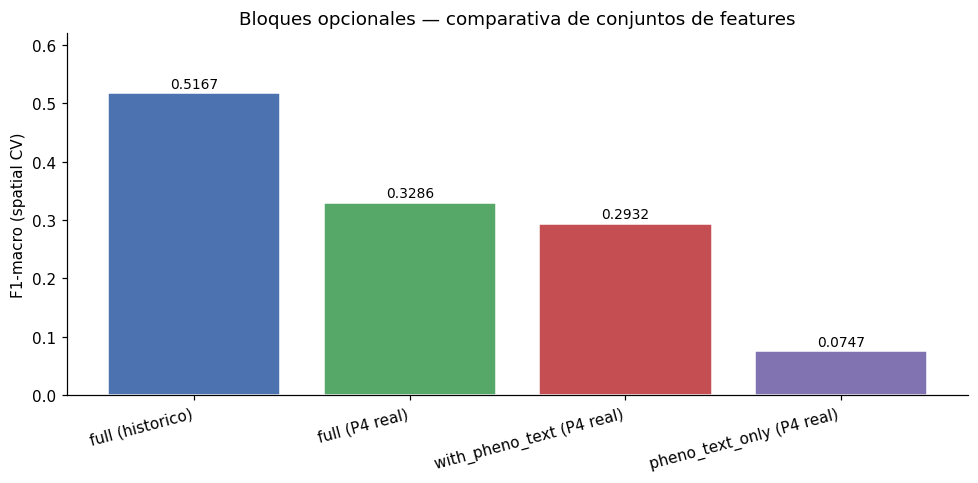

In [4]:
_fig_optional = REPO / 'paper/figures/us-023-preview/ablation_optional_blocks.png'
if _fig_optional.exists():
    display(Markdown('**Figura — bloques opcionales evaluados contra el conjunto `full`:**'))
    display(Image(filename=str(_fig_optional)))
else:
    display(Markdown('Figura `ablation_optional_blocks.png` no disponible en disco.'))


**Figura — leakage geometrico (`full` vs `no_geom`):**

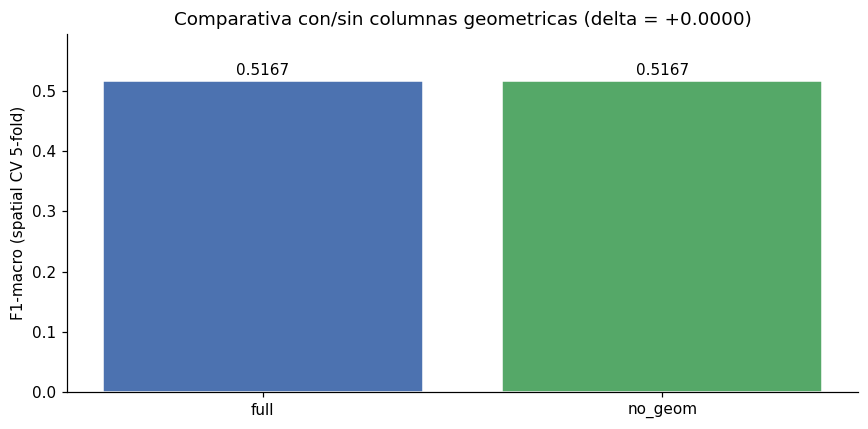

In [5]:
_fig_geom = REPO / 'paper/figures/us-023-preview/ablation_geom_comparison.png'
if _fig_geom.exists():
    display(Markdown('**Figura — leakage geometrico (`full` vs `no_geom`):**'))
    display(Image(filename=str(_fig_geom)))
else:
    display(Markdown('Figura `ablation_geom_comparison.png` no disponible en disco.'))


<a id="sec3"></a>
## 3. Baseline v2 — 3 modelos sobre el conjunto ganador

Con el conjunto de features saneado (`no_geom`, sin las 3 columnas que introducían el atajo regional), se reentrenan los **3 modelos canónicos del Avance 3** sobre 85.951 parcelas con la misma validación cruzada espacial de 5 pliegues con buffer de 1 km:

- **XGBoost** (tabular, gradient boosting, NaN-aware).
- **TempCNN** (Pelletier et al. 2019, importado de `breizhcrops.models`).
- **InceptionTime** (Fawaz et al. 2020, importado de `breizhcrops.models`).

Wall clock real: 49,9 min en RTX 4070 (XGBoost en CPU, modelos temporales en GPU). Los artefactos del entrenamiento (3 run IDs MLflow + tabla + figura) viven en disco; este notebook solo los presenta.

**Detalle completo:** [`../baseline/04b_baseline_v2.ipynb`](../baseline/04b_baseline_v2.ipynb).


In [6]:
_v2_path = REPO / 'reports/baseline/model_comparison_v2/model_comparison_v2.parquet'
df_v2 = pl.read_parquet(_v2_path)
display(Markdown('**Resultados Baseline v2 — 3 modelos sobre conjunto saneado:**'))
display(df_v2.select([
    'model', 'f1_macro', 'f1_weighted', 'miou', 'accuracy', 'kappa', 'train_time_s',
]))


**Resultados Baseline v2 — 3 modelos sobre conjunto saneado:**

model,f1_macro,f1_weighted,miou,accuracy,kappa,train_time_s
str,f64,f64,f64,f64,f64,f64
"""xgboost""",0.409421,0.691715,0.311504,0.725693,0.654556,436.624102
"""inceptiontime""",0.189803,0.194696,0.112386,NaN,0.149657,2100.557603
"""tempcnn""",0.143528,0.108884,0.081791,NaN,0.09084,457.07221


**Figura — comparativa visual de los 3 modelos v2:**

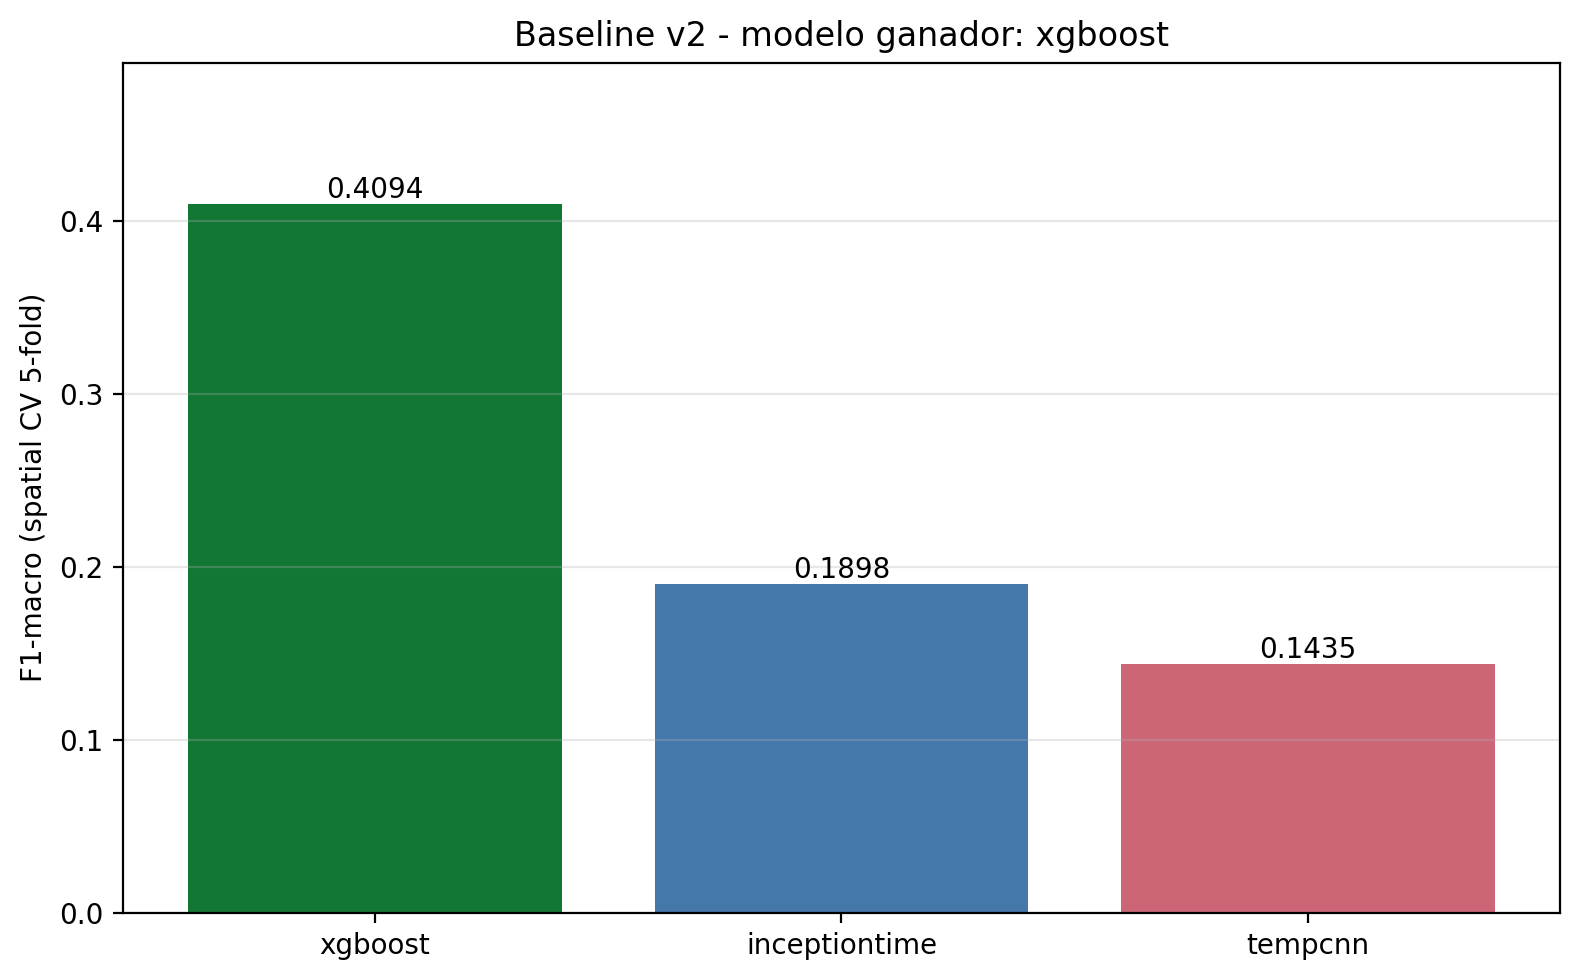

In [7]:
_fig_v2 = REPO / 'paper/figures/us-023-preview/model_comparison_v2.png'
if _fig_v2.exists():
    display(Markdown('**Figura — comparativa visual de los 3 modelos v2:**'))
    display(Image(filename=str(_fig_v2)))
else:
    display(Markdown('Figura `model_comparison_v2.png` no disponible en disco.'))


<a id="sec4"></a>
## 4. Conclusiones consolidadas

Este recorrido cierra la fase baseline con cinco hallazgos principales que orientan las fases siguientes del proyecto.

### Elección y comparación de modelos

Se evaluó XGBoost como modelo tabular fuerte sobre el vector combinado AlphaEarth + índices espectrales + temporales + terreno + clima. La iteración posterior incorporó dos arquitecturas temporales (TempCNN, InceptionTime) reentrenadas sobre el conjunto saneado. El criterio de selección del modelo de referencia es F1-macro sobre validación cruzada espacial de 5 pliegues, con desempate por F1-weighted y mIoU. XGBoost queda como referencia tabular (F1-macro 0,4094); TempCNN (0,1435) e InceptionTime (0,1898) quedan como candidatos para combinarse con XGBoost en la fase de modelos agregados.

### Análisis de características

La ingeniería de características validó con SHAP que la mayoría de las top-20 variables son dimensiones del embedding AlphaEarth — lo que justifica tratar el embedding como base. La iteración posterior probó cuatro bloques opcionales: leakage geométrico (descartado por proxy regional), FarSLIP (diferido hasta extender el matching al dataset completo), descripción fenológica textual vía Gemini Flash 3.5 sobre 1.080 parcelas balanceadas (delta vs full = -0,0354, queda diferido), firma espectral REP (diferido salvo confirmación en futuras corridas). El conjunto de features ganador es `no_geom` (185 columnas, sin las 3 columnas geométricas).

### Validación y diagnóstico de ajuste

La validación cruzada espacial con buffer de 1 km entre pliegues garantiza que parcelas vecinas no queden a la vez en entrenamiento y validación; las métricas reportadas reflejan capacidad de generalizar a regiones no vistas. Las curvas de aprendizaje y validación del notebook original muestran que el baseline NO sobreajusta: el techo es estructural — perder la dimensión temporal al resumir el año en un vector. El diagnóstico explícito reporta ajuste adecuado con exactitud limitada por la capacidad del modelo.

### Métricas reportadas

La métrica principal es **F1-macro**, que penaliza fuerte a las clases minoritarias en un problema con desbalance severo y 18 clases efectivas. Se reportan además F1-weighted (referencia global), mIoU (compatible con la fase siguiente de segmentación densa), accuracy y Cohen kappa.

### Brecha al objetivo del proyecto

El umbral de referencia F1-macro >= 0,60 no se alcanza con el baseline tabular (XGBoost 0,4094) ni con los modelos temporales (0,14-0,19). Los bloques opcionales tabulares (FarSLIP, descripción fenológica textual, firma espectral) produjeron deltas <= 0 sobre el baseline saneado, así que la brecha al umbral no se cierra agregando más características tabulares. El avance vendrá de las arquitecturas densas (U-Net, U-TAE, TSViT, Swin-UNETR) y de combinar varios modelos.

### Lo que sigue

Con el baseline saneado, los conjuntos de features con decisión documentada y los tres modelos canónicos reentrenados, la fase siguiente arranca el modelado denso sobre PASTIS-R con un techo cuantificado a batir. XGBoost queda como referencia tabular y los dos modelos temporales pasan al banco de aprendices base para los modelos agregados posteriores.
